# Figura 12 — Impacto do overhead de cabeçalhos HTTP

Reproduz o gráfico equivalente à **Figura 12** do artigo *Comparison of WebSocket and HTTP Protocol Performance* (Łasocha & Badurowicz, 2021): tempo médio de envio (POST) e recebimento (GET) de **100 cópias fixas** de texto via HTTP, variando o número de cabeçalhos extras adicionados a cada requisição (0, 10, 50, 100, 200, 300).

**Nota sobre a metodologia (seção 4.5 do artigo)**: diferente das Figuras 6–11, aqui o número de cópias é **fixado em 100** — só o overhead varia. É por isso que os arquivos `http-*-oh10.csv` até `http-*-oh300.csv` têm somente `copies=100`; isso é o comportamento esperado do teste, não um bug. O único arquivo com a varredura completa de cópias é `oh0` (`http-send-oh0.csv` / `http-receive-oh0.csv`), porque ele serve dois propósitos: baseline do teste de overhead (aqui) **e** dado bruto das Figuras 6/7 — este notebook filtra apenas as linhas com `copies == 100` dele para usar como o ponto `overhead=0`.

**Diferença em relação ao artigo original**: a Figura 12 original também varia por navegador (só Google Chrome é mostrado, mas comparado entre 2 laptops — 2 séries de hardware). Aqui, com um único perfil de hardware, temos 2 séries: envio e recebimento.

## Configuração e carga dos dados

Este notebook espera estar em `data/notebook/` dentro do projeto, e busca os CSVs em `results/csv/` (dois níveis acima, depois entrando em `csv/`).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# notebook está em data/notebook/ -> sobe 2 níveis (data/notebook -> results -> raiz)
# e entra em results/csv
CSV_DIR = Path.cwd().parents[1] / "results" / "csv"

OVERHEAD_LEVELS = [0, 10, 50, 100, 200, 300]
FIXED_COPIES = 100  # cópias fixas usadas em todo o teste de overhead (seção 4.5 do artigo)

print(f"Diretório de CSVs: {CSV_DIR.resolve()}")
print(f"Existe? {CSV_DIR.exists()}\n")
for direction in ["send", "receive"]:
    for oh in OVERHEAD_LEVELS:
        path = CSV_DIR / f"http-{direction}-oh{oh}.csv"
        print(f" - http-{direction}-oh{oh}.csv: {'encontrado' if path.exists() else 'NÃO encontrado'}")

Diretório de CSVs: /home/ryan-correia/Área de trabalho/.projetos/repositorios/github/ComputerNetworksManagement/ifpb/converged_networks/advanced_project/results/csv
Existe? True

 - http-send-oh0.csv: encontrado
 - http-send-oh10.csv: encontrado
 - http-send-oh50.csv: encontrado
 - http-send-oh100.csv: encontrado
 - http-send-oh200.csv: encontrado
 - http-send-oh300.csv: encontrado
 - http-receive-oh0.csv: encontrado
 - http-receive-oh10.csv: encontrado
 - http-receive-oh50.csv: encontrado
 - http-receive-oh100.csv: encontrado
 - http-receive-oh200.csv: encontrado
 - http-receive-oh300.csv: encontrado


## Carregamento e checagem de integridade

Para cada nível de overhead, carrega o CSV correspondente e filtra apenas as linhas com `copies == 100` (no caso de `oh0`, isso descarta as demais quantidades de cópias que esse arquivo também contém). Avisa se algum arquivo estiver faltando, sem linhas de `copies=100`, ou com menos de 10 repetições.

In [7]:
EXPECTED_RUNS = 10

def load_overhead_series(direction):
    rows = []
    for oh in OVERHEAD_LEVELS:
        path = CSV_DIR / f"http-{direction}-oh{oh}.csv"
        if not path.exists():
            print(f"Arquivo não encontrado: {path.name}")
            continue
        df = pd.read_csv(path)
        df_fixed = df[df["copies"] == FIXED_COPIES]
        if df_fixed.empty:
            print(f"{path.name} não tem nenhuma linha com copies={FIXED_COPIES}")
            continue
        if len(df_fixed) != EXPECTED_RUNS:
            print(f"{path.name}: {len(df_fixed)} linhas com copies={FIXED_COPIES} (esperado {EXPECTED_RUNS})")
        rows.append({
            "overhead": oh,
            "mean_ms": df_fixed["time_ms"].mean(),
            "std_ms": df_fixed["time_ms"].std(),
            "min_ms": df_fixed["time_ms"].min(),
            "max_ms": df_fixed["time_ms"].max(),
            "n": len(df_fixed),
        })
    return pd.DataFrame(rows).set_index("overhead")

print("--- Envio (POST) ---")
send_summary = load_overhead_series("send")
print("--- Recebimento (GET) ---")
receive_summary = load_overhead_series("receive")

print("\nEnvio:")
display(send_summary)
print("Recebimento:")
display(receive_summary)

--- Envio (POST) ---
--- Recebimento (GET) ---

Envio:


,mean_ms,std_ms,min_ms,max_ms,n
overhead,,,,,
0,91.3757,17.274294,68.145,119.199,10
10,83.8050,10.642876,71.624,103.184,10
50,145.8906,17.444550,115.873,176.929,10
100,295.4093,32.193795,245.361,335.514,10
200,839.8297,39.844324,785.655,931.748,10
300,1816.0359,44.900762,1760.726,1903.641,10


Recebimento:


,mean_ms,std_ms,min_ms,max_ms,n
overhead,,,,,
0,71.8444,8.905651,60.394,85.994,10
10,80.3259,15.049608,57.464,104.938,10
50,132.5675,23.638552,103.612,168.406,10
100,257.0700,33.402573,222.120,321.836,10
200,693.4028,31.038139,651.269,760.439,10
300,1390.6946,27.793551,1365.026,1457.872,10


## Figura 12 — Overhead de cabeçalhos HTTP (100 cópias)

Gráfico de barras agrupadas: para cada nível de overhead, 2 barras lado a lado (envio e recebimento).

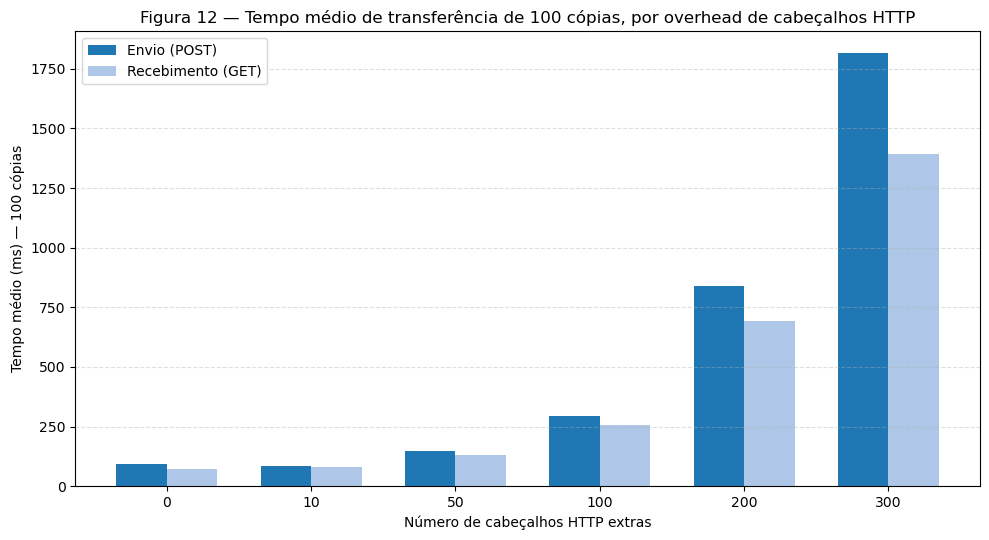

In [8]:
def plot_overhead(send_df, receive_df, title):
    labels = [str(oh) for oh in OVERHEAD_LEVELS]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.bar(x - width/2, send_df["mean_ms"], width, label="Envio (POST)", color="#1f77b4")
    ax.bar(x + width/2, receive_df["mean_ms"], width, label="Recebimento (GET)", color="#aec7e8")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_xlabel("Número de cabeçalhos HTTP extras")
    ax.set_ylabel("Tempo médio (ms) — 100 cópias")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    return fig, ax

plot_overhead(
    send_summary,
    receive_summary,
    "Figura 12 — Tempo médio de transferência de 100 cópias, por overhead de cabeçalhos HTTP",
)
plt.show()

## Queda de performance relativa ao baseline (overhead=0)

Replica a conclusão da seção 4.5 do artigo: poucos cabeçalhos extras têm impacto desprezível, mas a partir de ~100 cabeçalhos a degradação passa a ser perceptível (o artigo original reporta cerca de 20% de queda em 100 cabeçalhos extras, com overhead de ~1900 bytes por requisição).

In [9]:
def pct_change_vs_baseline(summary):
    baseline = summary["mean_ms"].loc[0]
    return ((summary["mean_ms"] - baseline) / baseline * 100).round(1)

comparison = pd.DataFrame({
    "Envio (ms)": send_summary["mean_ms"].round(1),
    "Envio (Δ% vs oh=0)": pct_change_vs_baseline(send_summary),
    "Recebimento (ms)": receive_summary["mean_ms"].round(1),
    "Recebimento (Δ% vs oh=0)": pct_change_vs_baseline(receive_summary),
})
comparison

,Envio (ms),Envio (Δ% vs oh=0),Recebimento (ms),Recebimento (Δ% vs oh=0)
overhead,,,,
0,91.4,0.0,71.8,0.0
10,83.8,-8.3,80.3,11.8
50,145.9,59.7,132.6,84.5
100,295.4,223.3,257.1,257.8
200,839.8,819.1,693.4,865.1
300,1816.0,1887.4,1390.7,1835.7


## Exportando a figura

Salva o gráfico como PNG em `data/plots`, pronto para o relatório.

Figura salva em: /home/ryan-correia/Área de trabalho/.projetos/repositorios/github/ComputerNetworksManagement/ifpb/converged_networks/advanced_project/data/plots


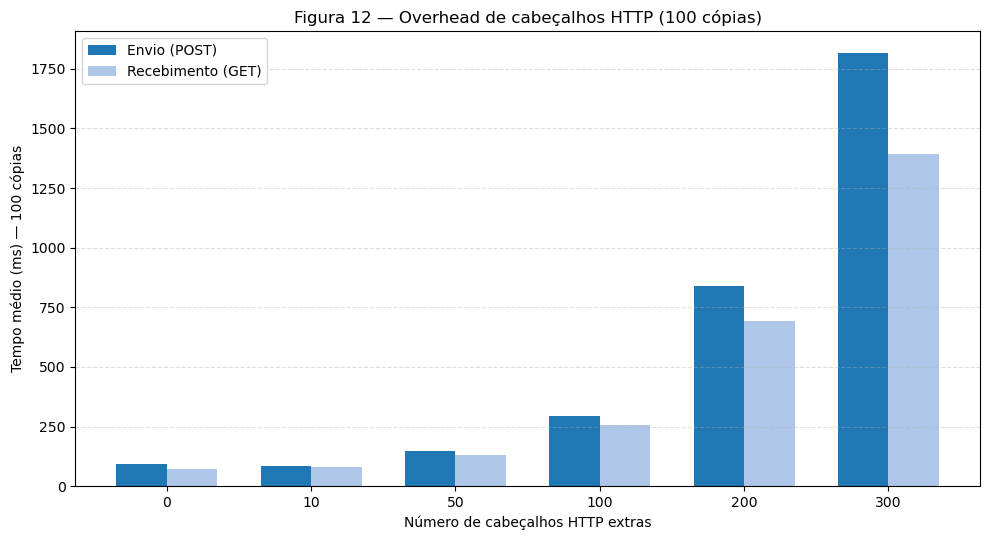

In [10]:
OUT_DIR = Path.cwd().parents[0] / "plots"
OUT_DIR.mkdir(exist_ok=True)

fig, _ = plot_overhead(
    send_summary,
    receive_summary,
    "Figura 12 — Overhead de cabeçalhos HTTP (100 cópias)",
)
fig.savefig(OUT_DIR / "figura12_http_overhead.png", dpi=150)
print(f"Figura salva em: {OUT_DIR.resolve()}")